In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split,cross_val_score,learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    mean_squared_error, mean_absolute_error, r2_score, ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, VotingClassifier, BaggingClassifier
)
from sklearn.tree import DecisionTreeClassifier


In [2]:
np.random.seed(42)
n = 800

age             = np.random.randint(22, 65, n)
income          = np.random.normal(55000, 20000, n).clip(15000, 150000)
loan_amount     = np.random.normal(20000, 8000, n).clip(2000, 60000)
credit_score    = np.random.normal(680, 80, n).clip(300, 850)
emp_years       = np.random.randint(0, 30, n)
dti_ratio       = loan_amount / income          # Debt-to-income
num_credit_lines= np.random.randint(1, 10, n)

# Target: default probability depends on credit score, dti, income
log_odds = (
    -0.03 * (credit_score - 680)
    + 3.5  * dti_ratio
    - 0.01 * (income / 1000)
    + 0.02 * age
    - 0.05 * emp_years
    + np.random.normal(0, 0.5, n)
)
prob_default = 1 / (1 + np.exp(-log_odds))
default = (prob_default > 0.5).astype(int)

loan_df = pd.DataFrame({
    'age': age,
    'income': income.round(0),
    'loan_amount': loan_amount.round(0),
    'credit_score': credit_score.round(0),
    'emp_years': emp_years,
    'dti_ratio': dti_ratio.round(4),
    'num_credit_lines': num_credit_lines,
    'default': default
})

loan_df.head(2)

,age,income,loan_amount,credit_score,emp_years,dti_ratio,num_credit_lines,default
0,60,44390.0,14116.0,794.0,12,0.3180,2,0
1,50,43484.0,29889.0,754.0,12,0.6874,1,0


In [4]:
print(loan_df['default'].value_counts().rename({0:'No Default', 1:'Default'}))
print(f"\nDefault rate: {loan_df['default'].mean()*100:.1f}%")

default
Default       512
No Default    288
Name: count, dtype: int64

Default rate: 64.0%


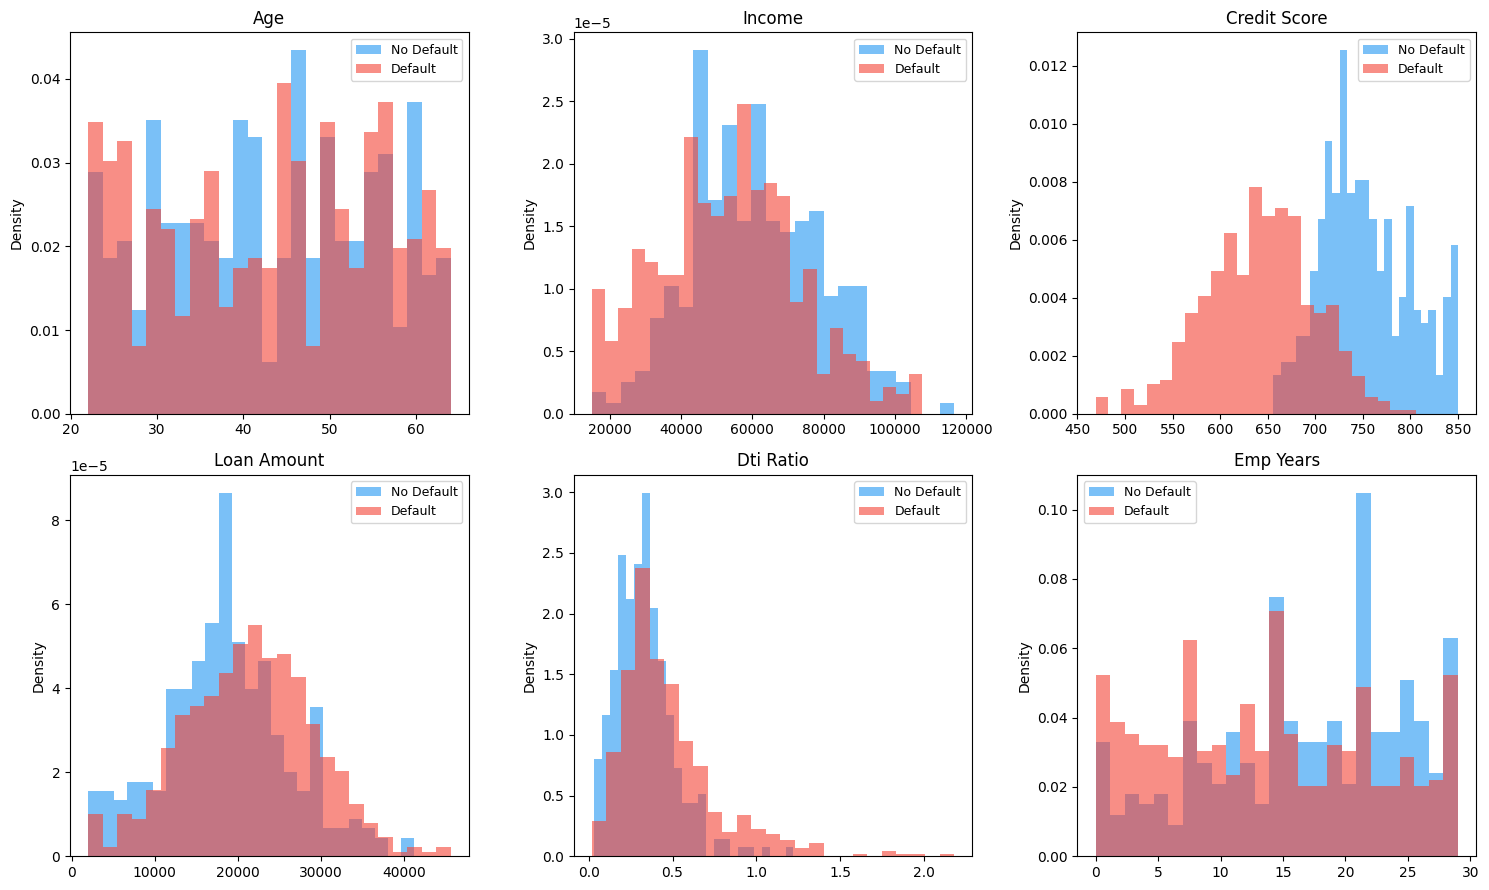

In [9]:
# exploaration of data

fig, axes = plt.subplots(2, 3, figsize=(15, 9))



features = ['age', 'income', 'credit_score', 'loan_amount', 'dti_ratio', 'emp_years']
colors   = ['#2196F3', '#F44336']


for ax, feat in zip(axes.flat, features):
    for cls, color, label in zip([0, 1], colors, ['No Default', 'Default']):
        data = loan_df[loan_df['default'] == cls][feat]
        ax.hist(data, bins=25, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('lr_eda.png', bbox_inches='tight')
plt.show()

In [10]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


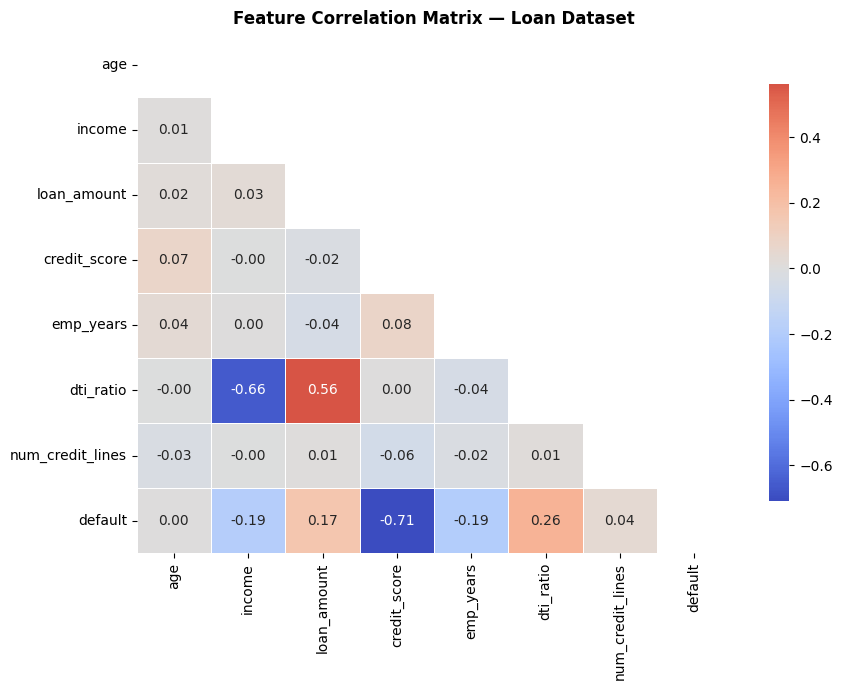

In [11]:
# Correlation heatmap
import seaborn as sns
fig, ax = plt.subplots(figsize=(9, 7))
corr = loan_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix — Loan Dataset', fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# 1.3 
X_lr = loan_df.drop('default', axis=1)
y_lr = loan_df['default']

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42, stratify=y_lr
)

# Feature scaling — CRITICAL for Logistic Regression

scaler_lr = StandardScaler()
X_train_lr_sc = scaler_lr.fit_transform(X_train_lr)
X_test_lr_sc  = scaler_lr.transform(X_test_lr)

print(f"Train size : {X_train_lr_sc.shape}")
print(f"Test  size : {X_test_lr_sc.shape}")
print(f"Train default rate : {y_train_lr.mean()*100:.1f}%")
print(f"Test  default rate : {y_test_lr.mean()*100:.1f}%")

Train size : (640, 7)
Test  size : (160, 7)
Train default rate : 64.1%
Test  default rate : 63.7%


In [ ]:
lr_model = LogisticRegression(
    C=0.9,            # Regularization strength (inverse) — smaller C = more regularization
    max_iter=500,
    solver='lbfgs',   # Limited-memory BFGS optimizer
    random_state=42
)

lr_model.fit(X_train_lr_sc, y_train_lr)

# Coefficients — what did the model learn?
coef_df = pd.DataFrame({
    'Feature': X_lr.columns,
    'Coefficient': lr_model.coef_[0],
    'Abs_Coef': np.abs(lr_model.coef_[0])
}).sort_values('Abs_Coef', ascending=False)
coef_df


,Feature,Coefficient,Abs_Coef
3,credit_score,-5.562001,5.562001
5,dti_ratio,2.209234,2.209234
4,emp_years,-1.023446,1.023446
0,age,0.652571,0.652571
1,income,-0.537556,0.537556
2,loan_amount,0.192544,0.192544
6,num_credit_lines,-0.107530,0.107530


In [14]:
print(coef_df.to_string(index=False))
print(f"\nIntercept: {lr_model.intercept_[0]:.4f}")


         Feature  Coefficient  Abs_Coef
    credit_score    -5.562001  5.562001
       dti_ratio     2.209234  2.209234
       emp_years    -1.023446  1.023446
             age     0.652571  0.652571
          income    -0.537556  0.537556
     loan_amount     0.192544  0.192544
num_credit_lines    -0.107530  0.107530

Intercept: 2.5577


In [19]:
y_pred_lr   = lr_model.predict(X_test_lr_sc)
y_proba_lr  = lr_model.predict_proba(X_test_lr_sc)[:, 1]

acc  = accuracy_score(y_test_lr, y_pred_lr)
prec = precision_score(y_test_lr, y_pred_lr)
rec  = recall_score(y_test_lr, y_pred_lr)
f1   = f1_score(y_test_lr, y_pred_lr)

# classification-report()

print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1 Score  : {f1*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test_lr, y_pred_lr, target_names=['No Default','Default']))

  Accuracy  : 93.75%
  Precision : 94.23%
  Recall    : 96.08%
  F1 Score  : 95.15%

Classification Report:
              precision    recall  f1-score   support

  No Default       0.93      0.90      0.91        58
     Default       0.94      0.96      0.95       102

    accuracy                           0.94       160
   macro avg       0.94      0.93      0.93       160
weighted avg       0.94      0.94      0.94       160



In [21]:
cv_scores = cross_val_score(lr_model, X_train_lr_sc, y_train_lr, cv=5, scoring='accuracy')


In [22]:
cv_scores

array([0.9609375, 0.9609375, 0.953125 , 0.9296875, 0.9609375])

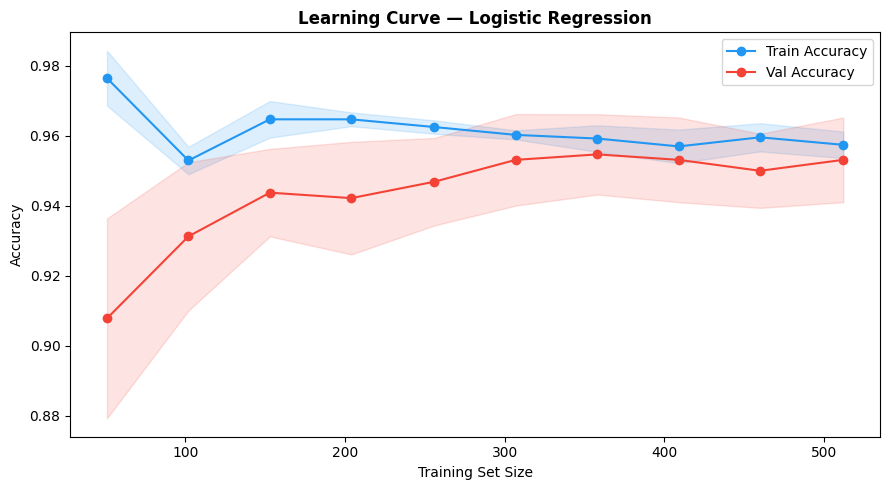

In [24]:
# Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    lr_model, X_train_lr_sc, y_train_lr,
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='accuracy'
)


plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#2196F3', label='Train Accuracy')
plt.plot(train_sizes, val_scores.mean(axis=1),   'o-', color='#F44336', label='Val Accuracy')
plt.fill_between(train_sizes,
    train_scores.mean(1)-train_scores.std(1),
    train_scores.mean(1)+train_scores.std(1), alpha=0.15, color='#2196F3')
plt.fill_between(train_sizes,
    val_scores.mean(1)-val_scores.std(1),
    val_scores.mean(1)+val_scores.std(1), alpha=0.15, color='#F44336')
plt.xlabel('Training Set Size'); plt.ylabel('Accuracy')
plt.title('Learning Curve — Logistic Regression', fontweight='bold')
plt.legend(); plt.tight_layout()
plt.show()


In [25]:
# naive bayes ?? text data 
np.random.seed(7)
n_spam = 300
n_ham  = 700
n_total = n_spam + n_ham

def gen_spam_features(n):
    return np.column_stack([
        np.random.poisson(8, n),    # free
        np.random.poisson(6, n),    # winner
        np.random.poisson(5, n),    # prize
        np.random.poisson(1, n),    # meeting
        np.random.poisson(1, n),    # lunch
        np.random.poisson(0.5, n),  # project
        np.random.poisson(4, n),    # click
        np.random.poisson(3, n),    # claim
        np.random.poisson(0.5, n),  # regards
        np.random.poisson(6, n),    # urgent
    ])

def gen_ham_features(n):
    return np.column_stack([
        np.random.poisson(0.5, n),
        np.random.poisson(0.3, n),
        np.random.poisson(0.2, n),
        np.random.poisson(5, n),
        np.random.poisson(4, n),
        np.random.poisson(6, n),
        np.random.poisson(1, n),
        np.random.poisson(0.5, n),
        np.random.poisson(5, n),
        np.random.poisson(0.3, n),
    ])

feat_names = ['free','winner','prize','meeting','lunch','project','click','claim','regards','urgent']

X_spam = gen_spam_features(n_spam)
X_ham  = gen_ham_features(n_ham)

X_nb = np.vstack([X_spam, X_ham]).astype(float)
y_nb = np.array([1]*n_spam + [0]*n_ham)

# Shuffle
idx = np.random.permutation(n_total)
X_nb, y_nb = X_nb[idx], y_nb[idx]

nb_df = pd.DataFrame(X_nb, columns=feat_names)
nb_df['label'] = y_nb

print("Shape:", nb_df.shape)
print("\nClass distribution:")
print(nb_df['label'].value_counts().rename({0:'Ham', 1:'Spam'}))
nb_df.head(8)


Shape: (1000, 11)

Class distribution:
label
Ham     700
Spam    300
Name: count, dtype: int64


,free,winner,prize,meeting,lunch,project,click,claim,regards,urgent,label
0,1.0,1.0,0.0,4.0,4.0,8.0,3.0,0.0,7.0,0.0,0
1,1.0,1.0,0.0,8.0,4.0,8.0,2.0,1.0,7.0,0.0,0
2,5.0,8.0,2.0,2.0,0.0,1.0,5.0,2.0,1.0,5.0,1
3,1.0,1.0,0.0,4.0,3.0,8.0,0.0,1.0,3.0,2.0,0
4,1.0,0.0,0.0,5.0,0.0,5.0,2.0,1.0,5.0,0.0,0
5,0.0,0.0,0.0,9.0,3.0,4.0,2.0,0.0,4.0,0.0,0
6,0.0,0.0,0.0,3.0,5.0,3.0,0.0,1.0,4.0,0.0,0
7,0.0,0.0,0.0,6.0,1.0,9.0,1.0,1.0,5.0,0.0,0


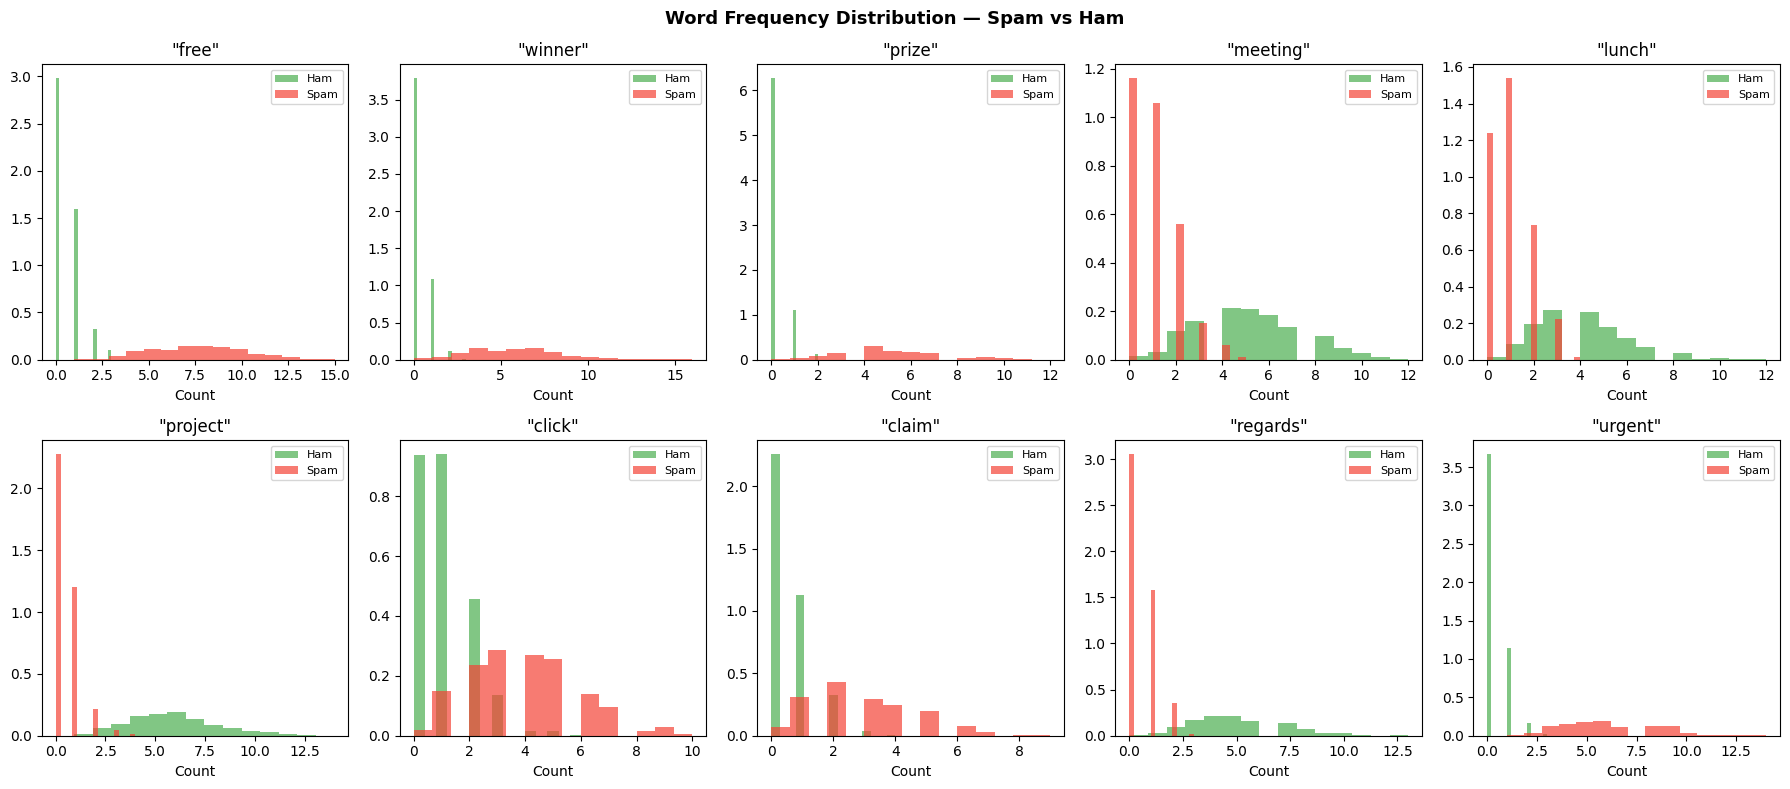

In [26]:
# spam ==> word occured in case spam ??
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('Word Frequency Distribution — Spam vs Ham', fontsize=13, fontweight='bold')

for ax, feat in zip(axes.flat, feat_names):
    ham_data  = nb_df[nb_df['label']==0][feat]
    spam_data = nb_df[nb_df['label']==1][feat]
    ax.hist(ham_data,  bins=15, alpha=0.7, color='#4CAF50', label='Ham',  density=True)
    ax.hist(spam_data, bins=15, alpha=0.7, color='#F44336', label='Spam', density=True)
    ax.set_title(f'"{feat}"')
    ax.legend(fontsize=8)
    ax.set_xlabel('Count')


plt.tight_layout()
plt.show()

In [29]:
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nb, y_nb, test_size=0.25, random_state=7, stratify=y_nb
)

nb_model = GaussianNB(
    var_smoothing=1e-9   # Laplace smoothing — avoids zero probability for unseen words
)

nb_model.fit(X_train_nb, y_train_nb)

print(f"\nClass priors (π): Ham={nb_model.class_prior_[0]:.3f}, Spam={nb_model.class_prior_[1]:.3f}")

means_df = pd.DataFrame(nb_model.theta_, columns=feat_names, index=['Ham','Spam']).T
print(means_df.round(3))


Class priors (π): Ham=0.700, Spam=0.300
           Ham   Spam
free     0.526  7.862
winner   0.276  5.982
prize    0.185  4.884
meeting  5.038  0.978
lunch    3.922  0.960
project  5.851  0.471
click    0.954  3.858
claim    0.512  2.782
regards  4.992  0.444
urgent   0.316  6.022


In [30]:
y_pred_nb  = nb_model.predict(X_test_nb)
y_proba_nb = nb_model.predict_proba(X_test_nb)[:, 1]

print("=" * 45)
print(f"  Accuracy  : {accuracy_score(y_test_nb, y_pred_nb)*100:.2f}%")
print(f"  Precision : {precision_score(y_test_nb, y_pred_nb)*100:.2f}%")
print(f"  Recall    : {recall_score(y_test_nb, y_pred_nb)*100:.2f}%")
print(f"  F1 Score  : {f1_score(y_test_nb, y_pred_nb)*100:.2f}%")

print(classification_report(y_test_nb, y_pred_nb, target_names=['Ham','Spam']))


  Accuracy  : 100.00%
  Precision : 100.00%
  Recall    : 100.00%
  F1 Score  : 100.00%
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00       175
        Spam       1.00      1.00      1.00        75

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



In [ ]:
# save it --> model object
# endpoint : rest endpoint ==>
# load the model ==> input -==?pass ==> FE

In [ ]:
# DE(cust_id) attribute ==> Help ==> DS ==> 
# validate==> clean the data => preprocess 
# ==> experimentation ( building model)==>evaluation
# ==> 100 experiments. ==> 1 pick ===> register ===> MLOPs ==> CI/CD pipeline
# data spurce ==> cleaning ==> preporcesisng ===>training code ==> pipeline ==>  model endpoint 
# https://rbyteai.com/predict ==> drop (accuracy)
# monitoring dashboard ==> accuracy to below 60%

In [31]:
np.random.seed(0)
n = 1000

satisfaction   = np.random.uniform(0.1, 1.0, n)
last_eval      = np.random.uniform(0.3, 1.0, n)
num_projects   = np.random.randint(2, 8, n)
avg_monthly_hrs= np.random.normal(200, 50, n).clip(100, 350)
tenure_yrs     = np.random.randint(1, 12, n)
work_accident  = np.random.binomial(1, 0.15, n)
promotion_5yr  = np.random.binomial(1, 0.05, n)
salary_cat     = np.random.choice([0, 1, 2], n, p=[0.5, 0.3, 0.2])  # low/medium/high

# Churn logic: unhappy + overworked + low salary → churn
churn_score = (
    -2.5 * satisfaction
    - 1.5 * last_eval
    + 0.3 * num_projects
    + 0.01 * (avg_monthly_hrs - 200)
    - 0.2 * tenure_yrs
    - salary_cat * 0.8
    + np.random.normal(0, 0.4, n)
)
churn = (churn_score > 0.2).astype(int)

churn_df = pd.DataFrame({
    'satisfaction':   satisfaction.round(3),
    'last_eval':      last_eval.round(3),
    'num_projects':   num_projects,
    'avg_monthly_hrs':avg_monthly_hrs.round(0),
    'tenure_yrs':     tenure_yrs,
    'work_accident':  work_accident,
    'promotion_5yr':  promotion_5yr,
    'salary_cat':     salary_cat,
    'churn':          churn
})

print("Shape:", churn_df.shape)
print("\nChurn rate:", churn_df['churn'].mean().round(3))
print(churn_df['churn'].value_counts().rename({0:'Stayed', 1:'Left'}))
churn_df.head(8)


Shape: (1000, 9)

Churn rate: 0.014
churn
Stayed    986
Left       14
Name: count, dtype: int64


,satisfaction,last_eval,num_projects,avg_monthly_hrs,tenure_yrs,work_accident,promotion_5yr,salary_cat,churn
0,0.594,0.715,5,267.0,7,0,0,1,0
1,0.744,0.307,5,108.0,4,0,0,1,0
2,0.642,0.633,5,254.0,10,0,0,0,0
3,0.590,0.796,7,260.0,2,1,0,1,0
4,0.481,0.331,6,200.0,6,0,0,1,0
5,0.681,0.916,3,201.0,3,1,0,1,0
6,0.494,0.664,6,223.0,7,0,0,0,0
7,0.903,0.321,6,188.0,9,0,0,0,0


In [32]:
X_ens = churn_df.drop('churn', axis=1)
y_ens = churn_df['churn']

X_train_ens, X_test_ens, y_train_ens, y_test_ens = train_test_split(
    X_ens, y_ens, test_size=0.2, random_state=0, stratify=y_ens
)


In [33]:
models_ens = {
    'Random Forest':     RandomForestClassifier(n_estimators=150, max_depth=8, random_state=0),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=0),
    'AdaBoost':          AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=0),
    'Bagging (DT)':      BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5),
                                           n_estimators=100, random_state=0),
    'Voting (Hard)':     VotingClassifier(estimators=[
                            ('rf', RandomForestClassifier(n_estimators=100, random_state=0)),
                            ('gb', GradientBoostingClassifier(n_estimators=100, random_state=0)),
                            ('ab', AdaBoostClassifier(n_estimators=50, random_state=0))
                         ], voting='hard'),
}

results = {}
for name, model in models_ens.items():
    model.fit(X_train_ens, y_train_ens)
    yp = model.predict(X_test_ens)
    results[name] = {
        'model': model,
        'accuracy':  accuracy_score(y_test_ens, yp),
        'precision': precision_score(y_test_ens, yp),
        'recall':    recall_score(y_test_ens, yp),
        'f1':        f1_score(y_test_ens, yp),
        'y_pred':    yp
    }


/Users/rahultiwari/Documents/02_Freelancing/Rbyte_project/Sathish_AI/test-env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rahultiwari/Documents/02_Freelancing/Rbyte_project/Sathish_AI/test-env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rahultiwari/Documents/02_Freelancing/Rbyte_project/Sathish_AI/test-env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted sa

In [34]:
results

{'Random Forest': {'model': RandomForestClassifier(max_depth=8, n_estimators=150, random_state=0),
  'accuracy': 0.985,
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0,
  'y_pred': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0])},
 'Gradient Boosting': {'model': GradientBoostingClassifier(max_depth=4, n_estimators=150, random_state=0),
  'accuracy': 0.975,

In [35]:
np.random.seed(1)
n = 600

area_sqft  = np.random.normal(1200, 400, n).clip(400, 3000)
num_rooms  = np.random.randint(1, 6, n)
age_years  = np.random.randint(0, 40, n)
floor_num  = np.random.randint(0, 25, n)
dist_metro = np.random.exponential(3, n).clip(0.2, 20)   # km to metro
locality   = np.random.choice([0,1,2], n, p=[0.4,0.35,0.25])  # 0=suburb,1=mid,2=prime

# True price formula (₹ Lakhs)
price = (
    0.06  * area_sqft
    + 3.5  * num_rooms
    - 0.4  * age_years
    + 0.8  * floor_num
    - 2.5  * dist_metro
    + 15   * locality
    + 20                   # base price
    + np.random.normal(0, 8, n)   # noise
).clip(10, 300)

house_df = pd.DataFrame({
    'area_sqft':  area_sqft.round(0),
    'num_rooms':  num_rooms,
    'age_years':  age_years,
    'floor_num':  floor_num,
    'dist_metro': dist_metro.round(2),
    'locality':   locality,
    'price_lakhs': price.round(2)
})

print("Shape:", house_df.shape)
print(f"Price range: ₹{price.min():.0f}L — ₹{price.max():.0f}L")
print(f"Mean price : ₹{price.mean():.1f}L")
house_df.describe().round(2)


Shape: (600, 7)
Price range: ₹30L — ₹209L
Mean price : ₹112.1L


,area_sqft,num_rooms,age_years,floor_num,dist_metro,locality,price_lakhs
count,600.00,600.00,600.00,600.00,600.00,600.00,600.00
mean,1229.30,3.01,19.67,12.07,2.74,0.84,112.11
std,392.20,1.41,11.79,7.33,2.64,0.80,29.54
min,400.00,1.00,0.00,0.00,0.20,0.00,29.99
25%,958.00,2.00,9.00,6.00,0.89,0.00,91.80
50%,1219.50,3.00,20.00,12.00,2.00,1.00,110.34
75%,1497.75,4.00,30.00,18.25,3.75,2.00,133.43
max,2783.00,5.00,39.00,24.00,20.00,2.00,209.40


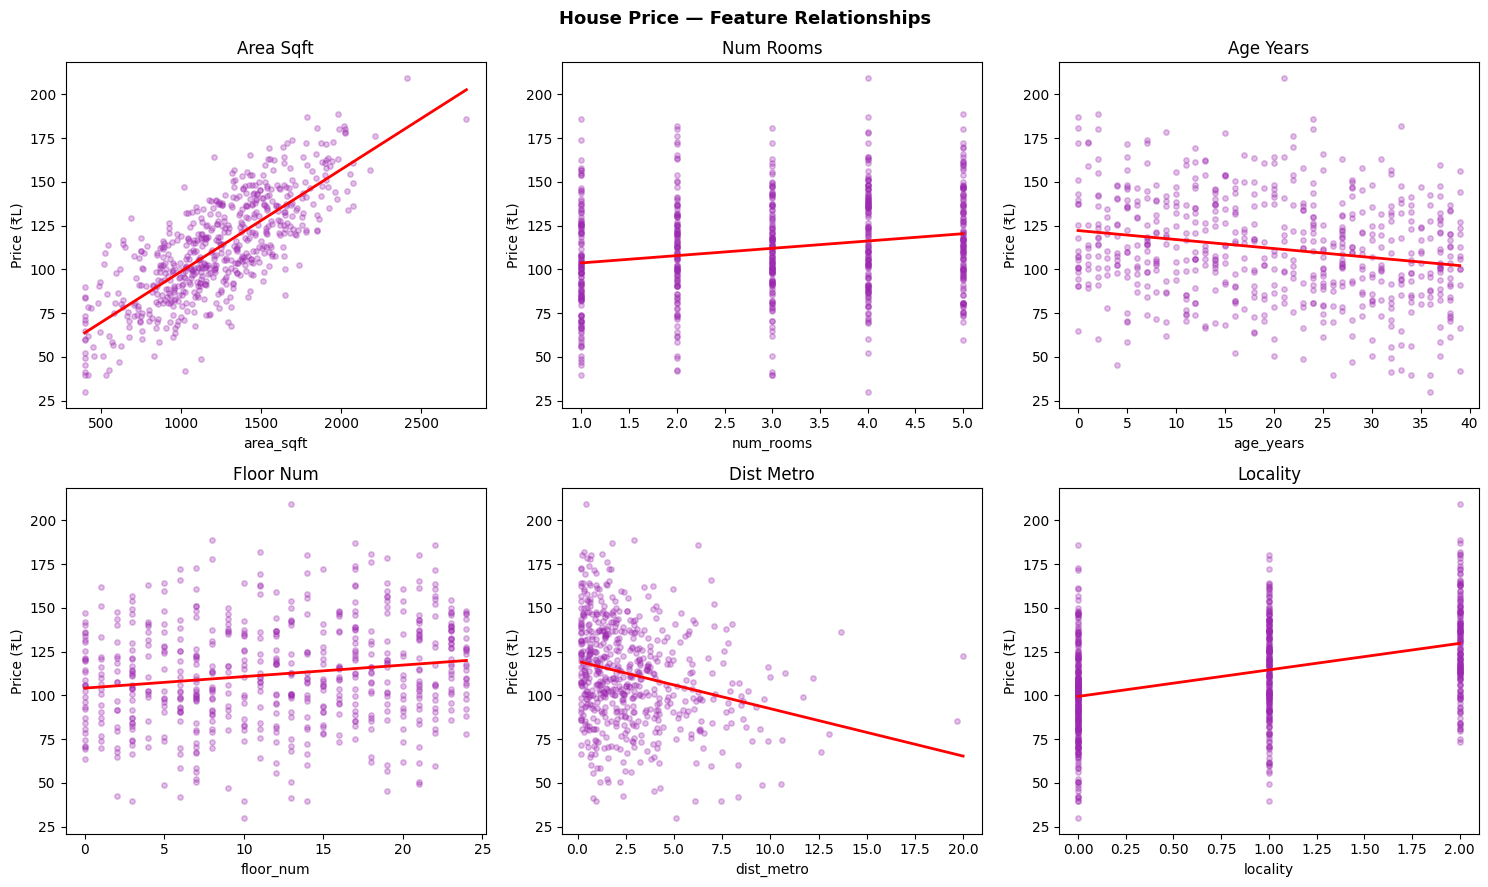

In [36]:
# Feature vs Price scatter plots
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('House Price — Feature Relationships', fontsize=13, fontweight='bold')

feats_linr = ['area_sqft','num_rooms','age_years','floor_num','dist_metro','locality']
for ax, feat in zip(axes.flat, feats_linr):
    ax.scatter(house_df[feat], house_df['price_lakhs'],
               alpha=0.3, s=15, color='#9C27B0')
    # Trend line
    z = np.polyfit(house_df[feat], house_df['price_lakhs'], 1)
    p = np.poly1d(z)
    xline = np.linspace(house_df[feat].min(), house_df[feat].max(), 100)
    ax.plot(xline, p(xline), 'r-', lw=2)
    ax.set_xlabel(feat); ax.set_ylabel('Price (₹L)')
    ax.set_title(feat.replace('_',' ').title())

plt.tight_layout()
plt.show()


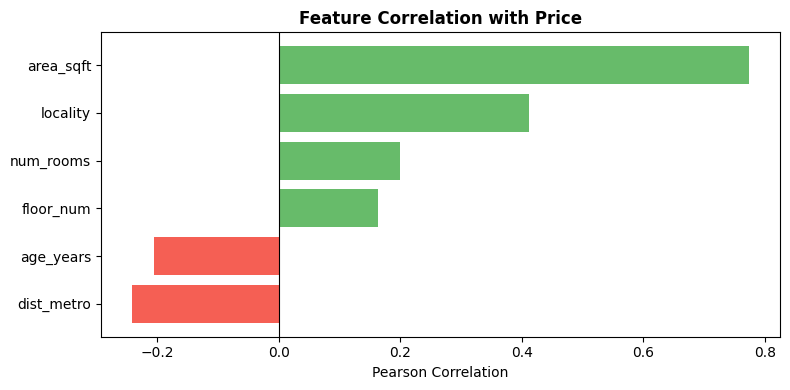

In [37]:
# Correlation with target
corr_with_price = house_df.corr()['price_lakhs'].drop('price_lakhs').sort_values()
plt.figure(figsize=(8, 4))
colors_corr = ['#F44336' if v < 0 else '#4CAF50' for v in corr_with_price]
plt.barh(corr_with_price.index, corr_with_price.values, color=colors_corr, alpha=0.85)
plt.axvline(0, color='black', lw=0.8)
plt.title('Feature Correlation with Price', fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()
